In [41]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms


In [42]:
import torch
x = torch.rand(5, 3)
print(x)
print(torch.cuda.is_available())  # Should return True
print(torch.cuda.device_count())  # Should show the number of GPUs


tensor([[0.5213, 0.6359, 0.9372],
        [0.6794, 0.2185, 0.8222],
        [0.1163, 0.7564, 0.2378],
        [0.4910, 0.4772, 0.1111],
        [0.7109, 0.6254, 0.5590]])
True
1


In [43]:
import torch
print(torch.__version__)  # Check PyTorch version
print(torch.version.cuda)  # Check CUDA version supported by PyTorch


2.5.1
12.4


In [44]:
input_dim = 784 # MNIST 28x28 = 784
hidden_dim = 200 # mid layer dim
latent_dim = 20 # latent variable z's dim
epochs = 30
learning_rate = 3e-4
batch_size = 32

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#device = torch.device("cpu")# if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [45]:
class Encoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, hidden_dim)
        self.linear_mu = nn.Linear(hidden_dim, latent_dim)
        self.linear_logvar = nn.Linear(hidden_dim, latent_dim)
    
    def forward(self, x):
        h = self.linear(x)
        h = F.relu(h)
        mu = self.linear_mu(h)
        logvar = self.linear_logvar(h) ## logvar as output to cover -inf to +inf
        sigma = torch.exp(0.5 * logvar)
        return mu, sigma

class Decoder(nn.Module):
    def __init__(self, latent_dim, hidden_dim, output_dim):
        super().__init__()
        self.linear1 = nn.Linear(latent_dim, hidden_dim)
        self.linear2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, z):
        h = self.linear1(z)
        h = F.relu(h)
        h = self.linear2(h)
        x_hat = F.sigmoid(h)
        return x_hat

def reparameterize(mu, sigma):
    eps = torch.randn_like(sigma)
    z = mu + eps * sigma
    return z

class VAE(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super().__init__()
        self.encoder = Encoder(input_dim, hidden_dim, latent_dim)
        self.decoder = Decoder(latent_dim, hidden_dim, input_dim)

    def get_loss(self, x):
        mu, sigma = self.encoder(x)
        z = reparameterize(mu, sigma)
        x_hat = self.decoder(z)
        #print(x.shape, x_hat.shape)
        #print((F.mse_loss(x_hat, x, reduction='none')).shape)
        
        batch_size = len(x)
        L1 = F.mse_loss(x_hat, x, reduction='sum')
        L2 = - torch.sum(1 + torch.log(sigma ** 2) - mu ** 2 - sigma ** 2)
        #print(L1.shape, mu.shape, sigma.shape, L2.shape, batch_size)
        return (L1 + L2) / batch_size


## Downloading Dataset

In [62]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(torch.flatten)
])
dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)
dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=2*batch_size,
    shuffle=True, 
    pin_memory=True,   # Speeds up data transfer to GPU
    num_workers=16,   # Adjust based on your CPU
    prefetch_factor=2,   # Prefetch batches ahead of time
    persistent_workers=True  # Keep workers alive across epochs
)

In [63]:
import os
os.cpu_count()

32

In [64]:
device

device(type='cuda')

In [48]:
import torch

def print_gpu_utilization():
    print(f"Allocated: {torch.cuda.memory_allocated() / 1024**2:.2f} MB")
    print(f"Cached:    {torch.cuda.memory_reserved() / 1024**2:.2f} MB")

print_gpu_utilization()

Allocated: 21.25 MB
Cached:    28.00 MB


In [66]:
model = VAE(input_dim, hidden_dim, latent_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr= learning_rate)
losses = []
count = 0

with torch.autograd.profiler.profile(use_cuda=True) as prof:
    for x, label in dataloader:
        x = x.to(device)
        loss = model.get_loss(x)
        loss.backward()
        optimizer.step()
        count += 1
        if count==5:
            break
print(prof.key_averages().table(sort_by="cuda_time_total"))


C:\Users\sonbe\AppData\Local\Temp\ipykernel_36128\490749281.py:6: FutureWarning: The attribute `use_cuda` will be deprecated soon, please use ``use_device = 'cuda'`` instead.
  with torch.autograd.profiler.profile(use_cuda=True) as prof:


-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                               Optimizer.step#Adam.step        10.11%       4.841ms        30.55%      14.631ms       2.926ms       2.028ms         4.01%      12.124ms       2.425ms             5  
                                                aten::t         4.81%       2.302ms        13.52%       6.474ms      53.952us       1.766ms         3.49%       7.675ms      63.958us           120  
    autog

In [ ]:
import torch.profiler as profiler

with profiler.profile(
    activities=[profiler.ProfilerActivity.CPU, profiler.ProfilerActivity.CUDA],
    on_trace_ready=profiler.tensorboard_trace_handler('./log'),
    record_shapes=True
) as prof:
    for x, label in dataloader:
        x = x.to(device)
        optimizer.zero_grad()
        loss = model.get_loss(x)
        loss.backward()
        optimizer.step()
        break
print(prof.key_averages().table(sort_by="cuda_time_total"))


## Training the model

In [67]:
model = VAE(input_dim, hidden_dim, latent_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr= learning_rate)
losses = []

# train
for epoch in range(epochs):
    loss_sum = 0.0
    cnt = 0

    for x, label in dataloader:
        x = x.to(device)
        optimizer.zero_grad()
        loss = model.get_loss(x)
        loss.backward()
        optimizer.step()

        loss_sum += loss.item()
        cnt += 1


    loss_avg = loss_sum / cnt
    losses.append(loss_avg)
    print(device)
    print(loss_avg)
    # Print GPU usage after each epoch
    print_gpu_utilization()

cuda
59.208038195872355
Allocated: 23.85 MB
Cached:    30.00 MB
cuda
47.02362339532198
Allocated: 23.85 MB
Cached:    30.00 MB
cuda
45.189107134398114
Allocated: 23.85 MB
Cached:    30.00 MB
cuda
43.905408025550436
Allocated: 23.85 MB
Cached:    30.00 MB
cuda
42.946846618326994
Allocated: 23.85 MB
Cached:    30.00 MB
cuda
42.30542836463782
Allocated: 23.85 MB
Cached:    30.00 MB
cuda
41.76468982574528
Allocated: 23.85 MB
Cached:    30.00 MB
cuda
41.380666948330685
Allocated: 23.85 MB
Cached:    30.00 MB
cuda
41.04041624577569
Allocated: 23.85 MB
Cached:    30.00 MB
cuda
40.75388114538782
Allocated: 23.85 MB
Cached:    30.00 MB
cuda
40.52927630084918
Allocated: 23.85 MB
Cached:    30.00 MB
cuda
40.350743568274005
Allocated: 23.85 MB
Cached:    30.00 MB
cuda
40.205290552395496
Allocated: 23.85 MB
Cached:    30.00 MB
cuda
40.031024351303
Allocated: 23.85 MB
Cached:    30.00 MB
cuda
39.93537629946971
Allocated: 23.85 MB
Cached:    30.00 MB
cuda
39.84181116994764
Allocated: 23.85 MB
Cached:

## Generate Image

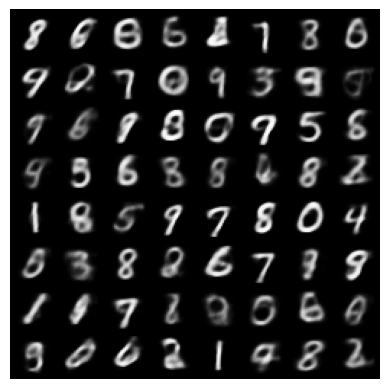

In [68]:
with torch.no_grad():  # disable gradient calculation under with paragraph to save memory
    sample_size = 64
    z = torch.randn(sample_size, latent_dim).to(device)  ## generate 64 flattened-image samples from z domain
    x = model.decoder(z)                      ## generate x from z using trained model
    generated_images = x.view(sample_size, 1, 28, 28).cpu()   ## convert it to 64 images.

grid_img = torchvision.utils.make_grid(  ## sort generated images into grid for visual representation
    generated_images,
    nrow=8,
    padding=2,
    normalize=True
)

plt.imshow(grid_img.permute(1,2,0))   # 
plt.axis('off')
plt.show()

In [51]:
z.shape

torch.Size([64, 20])

In [53]:
z[1]

tensor([ 1.7212, -0.2781,  0.4341,  0.4806,  1.5639,  1.2977, -0.2027,  0.3895,
        -1.2741,  0.1706, -0.3069,  0.2468, -0.8433,  0.4729, -1.1126,  0.4305,
         0.7005,  1.0709, -0.9724,  0.4806], device='cuda:0')